In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cihan063/autism-image-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\vv075\.cache\kagglehub\datasets\cihan063\autism-image-data\versions\1


In [5]:
! pip install pillow
import os
from PIL import Image
import shutil

def flip_images(input_dir, output_dir):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Iterate over all the files in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):  # Add more formats if needed
            img_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)
            output_path_flipped = os.path.join(output_dir, "_flipped" + filename)
            img = Image.open(img_path)

            shutil.copy(img_path, output_path)
#             print(f"Copied and saved: {output_path}")

            # Flip the image horizontally
            flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)

            # Save the flipped image to the output directory
            flipped_img.save(output_path_flipped)
#             print(f"Flipped and saved: {output_path_flipped}")

inputdir = "/kaggle/input/autism-image-data/AutismDataset/consolidated/Autistic"
outputdir = "/kaggle/output/augmented/Autistic"

input_dir_non = "/kaggle/input/autism-image-data/AutismDataset/consolidated/Non_Autistic"
output_dir_non = "/kaggle/output/augmented/Non_Autistic"

flip_images(inputdir, outputdir)
flip_images(input_dir_non, output_dir_non)

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/autism-image-data/AutismDataset/consolidated/Autistic'

In [ ]:
def count_files(folder_path):
    # Initialize a counter for the number of files
    num_files = 0

    # Iterate through all files in the folder
    for _, _, files in os.walk(folder_path):
        num_files += len(files)

    print(f"Number of files in {folder_path}: {num_files}")

folder_path = "/kaggle/output/augmented/Autistic"
folder_path1 = "/kaggle/output/augmented/Non_Autistic"
count_files(folder_path)
count_files(folder_path1)


In [ ]:
! pip install split_folders

In [ ]:
import numpy as np
import pandas as pd
import splitfolders
import tensorflow as tf
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense,Activation,Dropout,Conv2D,MaxPooling2D,BatchNormalization,Flatten
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, load_model, Sequential

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import KFold
from mlxtend.plotting import plot_confusion_matrix
import itertools

import matplotlib.pyplot as plt
import datetime
import matplotlib.image as mping
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.applications import VGG19, VGG16

In [ ]:
# Path to the augmented data
loc = "/kaggle/output/augmented"

In [ ]:
# Create output directories
# os.makedirs('output', exist_ok=True)
os.makedirs('output/train', exist_ok=True)
os.makedirs('output/val', exist_ok=True)
os.makedirs('output/test', exist_ok=True)

In [ ]:
# Split data into training, validation, and test sets
splitfolders.ratio(loc, output="output", seed=42, ratio=(0.80, 0.1, 0.1))

In [ ]:
# Load data
train_dir = "output/train"
test_dir = "output/test"
val_dir = "output/val"

In [ ]:
train_data = image_dataset_from_directory(train_dir, batch_size=128, image_size=(224, 224), label_mode='categorical', shuffle=True, seed=0)
test_data = image_dataset_from_directory(test_dir, batch_size=128, image_size=(224, 224), label_mode='categorical', shuffle=False, seed=0)
val_data = image_dataset_from_directory(val_dir, batch_size=128, image_size=(224, 224), label_mode='categorical', shuffle=False, seed=0)

In [ ]:
class_names = train_data.class_names
class_count = len(class_names)

In [ ]:
# Function to create a model
def create_model(model_name):
    input_shape = (224, 224, 3)
    base_model = None

    if model_name == 'VGG19':
        base_model = VGG19(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'VGG16':
        base_model = VGG16(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')

    x = base_model.output
    x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.002)(x)
    x = Dense(128, activation='sigmoid')(x)
    x = Dropout(rate=0.5, seed=42)(x)
    output = Dense(class_count, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
# Function to train and evaluate a model
def train_and_evaluate_model(model, train_data, val_data, test_data, model_name):
    if model_name == 'VGG19':
        ep = 70
    elif model_name == 'VGG16':
        ep = 50

    early_stopper = tf.keras.callbacks.EarlyStopping(patience=10, min_delta=0.01, verbose=1)
    history = model.fit(train_data, epochs=60, validation_data=val_data)
    history_df = pd.DataFrame(history.history)
    history_df

    test_loss, test_accuracy = model.evaluate(test_data)
    print(f"Test Accuracy for {model_name}:", test_accuracy)

    test_data_array = []
    labels_array = []
    for images, labels in test_data:
        test_data_array.append(images.numpy())
        labels_array.append(labels.numpy())

    X_test = np.concatenate(test_data_array, axis=0)
    y_test = np.concatenate(labels_array, axis=0)

    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    y_pred = tf.keras.utils.to_categorical(y_pred, num_classes=2)

    print(classification_report(y_test, y_pred))
    y_pred = np.argmax(y_pred, axis=1)
    y_test = np.argmax(y_test, axis=1)

    print(f"Test Accuracy for {model_name}:", test_accuracy)

    plt.figure(figsize=(12, 8))
    sns.lineplot(data=history_df.loc[:, ["accuracy", "val_accuracy"]], palette=['b', 'r'], dashes=False)
    sns.set_style("whitegrid")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"Training and Validation Accuracy for {model_name}")

    plt.figure(figsize=(12, 8))
    sns.lineplot(data=history_df.loc[:, ["loss", "val_loss"]], palette=['b', 'r'], dashes=False)
    sns.set_style("whitegrid")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss for {model_name}")


    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, cmap='crest', annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.5161 - loss: 1.2425 - val_accuracy: 0.5136 - val_loss: 1.2414
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5837 - loss: 0.9819 - val_accuracy: 0.6344 - val_loss: 0.8717
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6747 - loss: 0.7642 - val_accuracy: 0.7262 - val_loss: 0.6148
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7264 - loss: 0.6070 - val_accuracy: 0.7619 - val_loss: 0.5124
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7842 - loss: 0.4878 - val_accuracy: 0.8333 - val_loss: 0.4005
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8363 - loss: 0.3825 - val_accuracy: 0.8282 - val_loss: 0.3998
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8574 - loss: 0.3431 - val_accuracy: 0.8554 - val_loss: 0.3389
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8840 - loss: 0.2696 - val_accuracy: 0.7925 - val_los

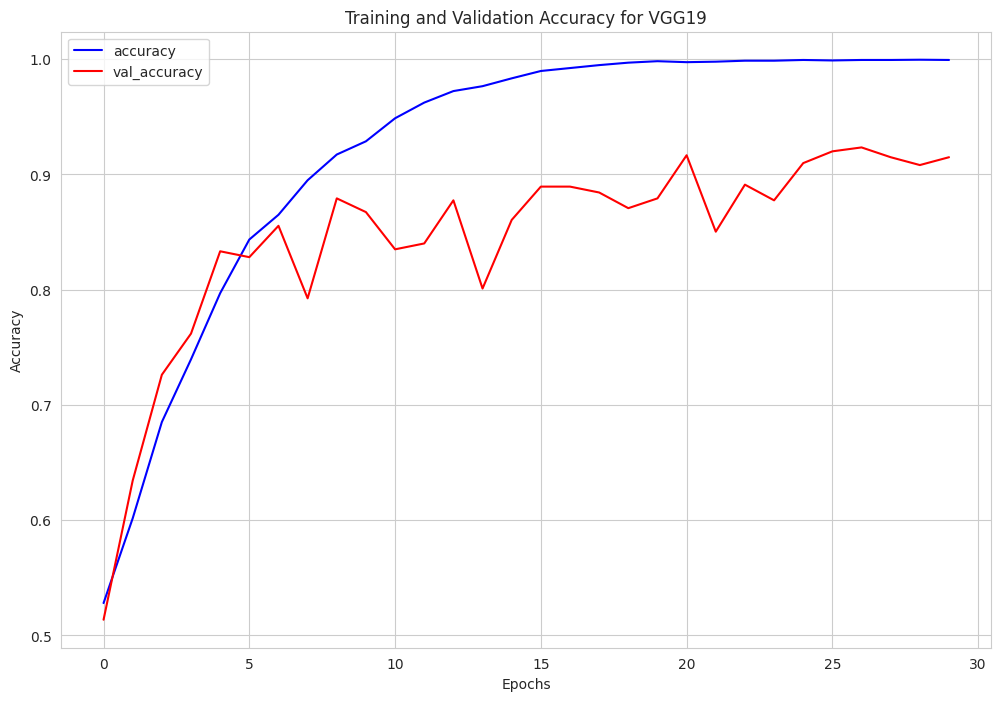

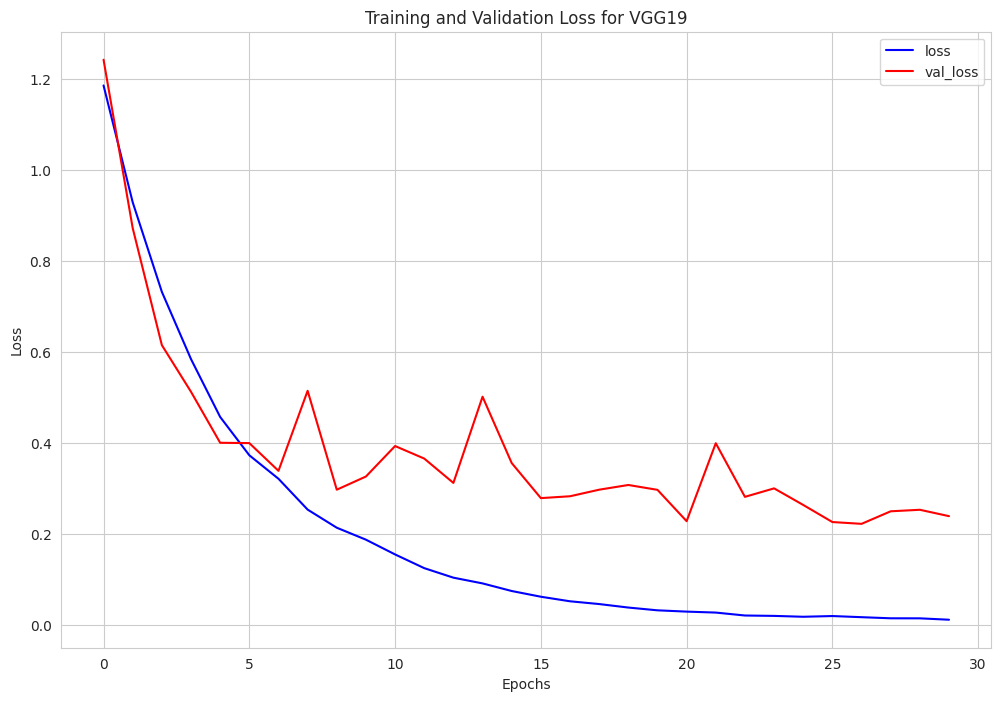

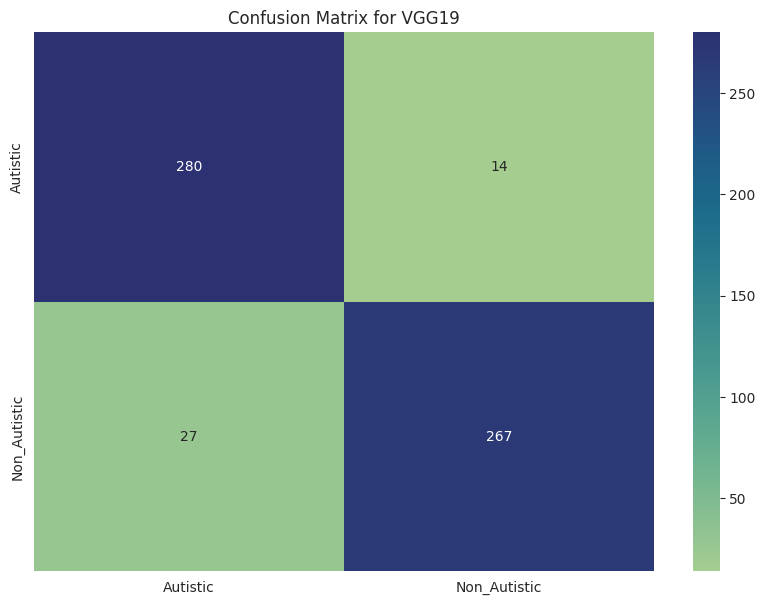

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5616 - loss: 0.7512 - val_accuracy: 0.7126 - val_loss: 0.5579
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7079 - loss: 0.5611 - val_accuracy: 0.7806 - val_loss: 0.4615
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7774 - loss: 0.4650 - val_accuracy: 0.8146 - val_loss: 0.4134
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8186 - loss: 0.3987 - val_accuracy: 0.8316 - val_loss: 0.3819
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8274 - loss: 0.3739 - val_accuracy: 0.8282 - val_loss: 0.3692
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8626 - loss: 0.3131 - val_accuracy: 0.8435 - val_loss: 0.3613
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8822 - loss: 0.2945 - val_accuracy: 0.8469 - val_loss: 0.3319
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8892 - loss: 0.2710 - val_accuracy: 0.8554 - val_loss:

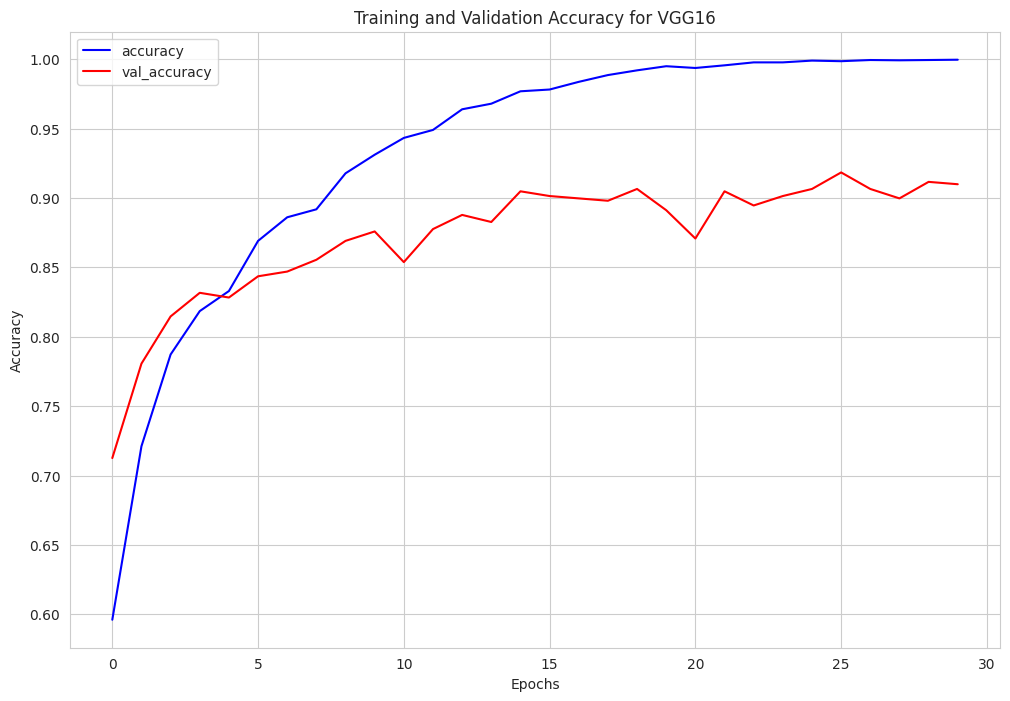

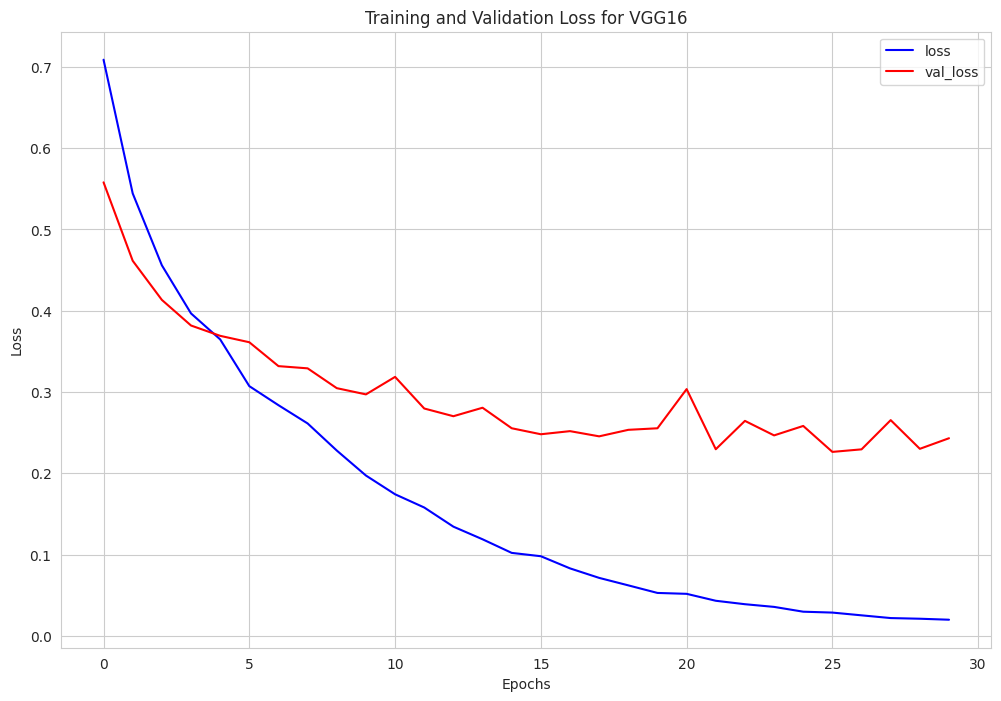

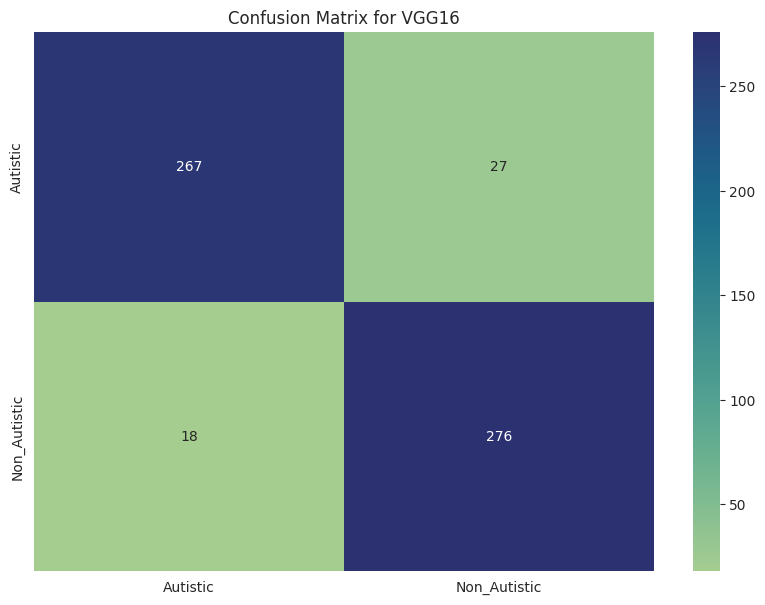

In [ ]:
model_names = ['VGG19', 'VGG16']

for model_name in model_names:
    model = create_model(model_name)
    train_and_evaluate_model(model, train_data, val_data, test_data, model_name)
    model.save(f"final_{model_name}.h5")  # Save after training


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image
import glob


In [ ]:
def predict_multiple_images(model, test_image_paths, class_names):
    plt.figure(figsize=(15, 10))

    for idx, img_path in enumerate(test_image_paths):
        # Read and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Normalize

        # Predict
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)

        # Actual label (folder name)
        actual_class = os.path.basename(os.path.dirname(img_path))

        # Plotting
        plt.subplot(1, len(test_image_paths), idx + 1)
        img_plot = mpimg.imread(img_path)
        plt.imshow(img_plot)
        plt.axis('off')
        plt.title(f"Actual: {actual_class}\nPredicted: {class_names[predicted_class]}")

    plt.tight_layout()
    plt.show()


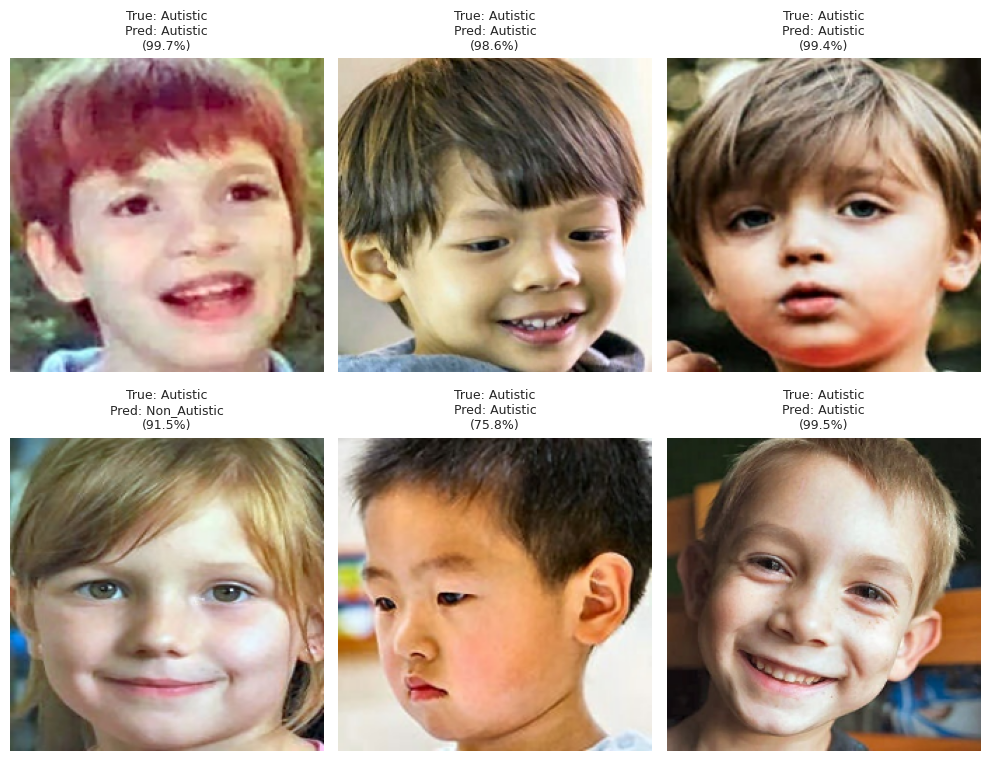

In [ ]:
def show_predictions(dataset, model, class_names, num_images=6):
    plt.figure(figsize=(10, 8))
    for images, labels in dataset.take(1):
        # Convert one-hot encoded labels to class indices if needed
        if len(labels.shape) > 1:  # If one-hot encoded
            labels = tf.argmax(labels, axis=1)
 ## for image path
        for i in range(min(num_images, len(images))):
            pred = model.predict(np.expand_dims(images[i], axis=0), verbose=0)
            plt.subplot(2, 3, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))


            # Get confidence percentage
            confidence = np.max(pred) * 100
            plt.title(
                f"True: {class_names[labels[i]]}\n"
                f"Pred: {class_names[np.argmax(pred)]}\n"
                f"({confidence:.1f}%)",
                fontsize=9
            )
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage
show_predictions(val_data, model, train_data.class_names)

In [1]:
!pip install timm

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import timm  # For ViT
import os


In [3]:
data_dir = "/content/AutismDataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = ImageFolder(os.path.join(data_dir, "val"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content/AutismDataset\\train'